# Notebook 04: Feature Engineering

   - Variables calendario cíclicas
   - Features de dominio (delta_presion, ratio_carga, etc.)
   - Componentes STL como features
   - Lags de señales crudas y features de ingeniería
   - Etiqueta RUL

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
import statsmodels.graphics.tsaplots as tsaplots
import os

sns.set_style('whitegrid')

ANALOG_COLS  = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
                'Oil_temperature', 'Motor_current', 'Caudal_impulses']
BINARY_COLS  = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
                'Pressure_switch', 'Oil_level']

In [2]:
df = pd.read_parquet('../data/processed/df_operacion.parquet')
print(f'Número de registros: {len(df):,}')
df

Número de registros: 114,740


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,id_segmento,regimen,id_sesion
0,2020-02-01 00:23:00,7.468667,8.511667,1.282667,-0.023333,8.509667,49.712500,5.740833,0.0,1.0,0.0,0.0,0.0,1.0,1.0,6.0,0,2,0
1,2020-02-01 00:24:00,8.343000,9.773000,1.671333,-0.023000,9.769333,49.854167,5.814167,0.0,1.0,1.0,0.0,0.0,1.0,1.0,6.0,0,2,0
2,2020-02-01 00:25:00,-0.020000,9.978333,9.970333,-0.022333,9.977000,51.975000,3.881667,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0
3,2020-02-01 00:26:00,-0.013333,9.860667,9.847000,-0.022667,9.860667,53.654167,3.865833,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0
4,2020-02-01 00:27:00,-0.012000,9.781000,9.766000,-0.022333,9.781000,53.241667,3.876250,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114735,2020-09-01 03:49:00,-0.013667,9.817000,9.805000,-0.021667,9.816667,67.154167,3.887500,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,331,1,366
114736,2020-09-01 03:50:00,-0.012000,9.710333,9.696667,-0.021000,9.710000,65.625000,3.925000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,331,1,366
114737,2020-09-01 03:51:00,-0.012000,9.612333,9.598333,-0.021000,9.612000,64.737500,3.863750,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,331,1,366
114738,2020-09-01 03:52:00,-0.012000,9.519000,9.505667,-0.021000,9.519000,64.541667,3.896250,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,331,1,366


## Variables calendario

In [3]:
df['hora_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.hour / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.hour / 24)

df['dia_sin']  = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
df['dia_cos']  = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)

df.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,...,Pressure_switch,Oil_level,Caudal_impulses,id_segmento,regimen,id_sesion,hora_sin,hora_cos,dia_sin,dia_cos
0,2020-02-01 00:23:00,7.468667,8.511667,1.282667,-0.023333,8.509667,49.712500,5.740833,0.0,1.0,...,1.0,1.0,6.0,0,2,0,0.0,1.0,-0.974928,-0.222521
1,2020-02-01 00:24:00,8.343000,9.773000,1.671333,-0.023000,9.769333,49.854167,5.814167,0.0,1.0,...,1.0,1.0,6.0,0,2,0,0.0,1.0,-0.974928,-0.222521
2,2020-02-01 00:25:00,-0.020000,9.978333,9.970333,-0.022333,9.977000,51.975000,3.881667,1.0,0.0,...,1.0,1.0,6.0,0,1,0,0.0,1.0,-0.974928,-0.222521
3,2020-02-01 00:26:00,-0.013333,9.860667,9.847000,-0.022667,9.860667,53.654167,3.865833,1.0,0.0,...,1.0,1.0,6.0,0,1,0,0.0,1.0,-0.974928,-0.222521
4,2020-02-01 00:27:00,-0.012000,9.781000,9.766000,-0.022333,9.781000,53.241667,3.876250,1.0,0.0,...,1.0,1.0,6.0,0,1,0,0.0,1.0,-0.974928,-0.222521


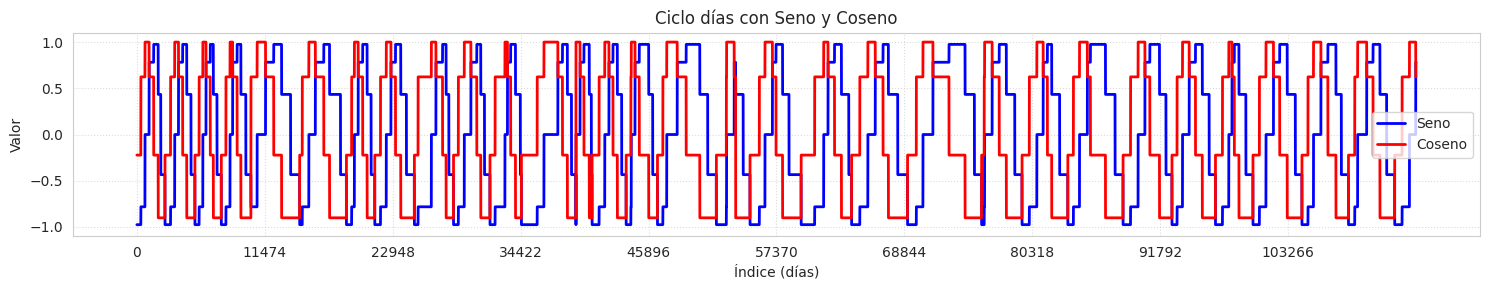

In [11]:
plt.figure(figsize=(15, 3))
plt.plot(df.index, df['dia_sin'], label='Seno', color='blue', linestyle='-', linewidth=2)
plt.plot(df.index, df['dia_cos'], label='Coseno', color='red', linestyle='-', linewidth=2)

plt.xlabel('Índice (días)')
plt.ylabel('Valor')
plt.title('Ciclo días con Seno y Coseno')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.xticks(np.arange(0, len(df), step=len(df)//10)) 
plt.ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

Registros en últimas 48h: 3142
De: 2020-08-27 04:03:00
A:  2020-09-01 03:53:00


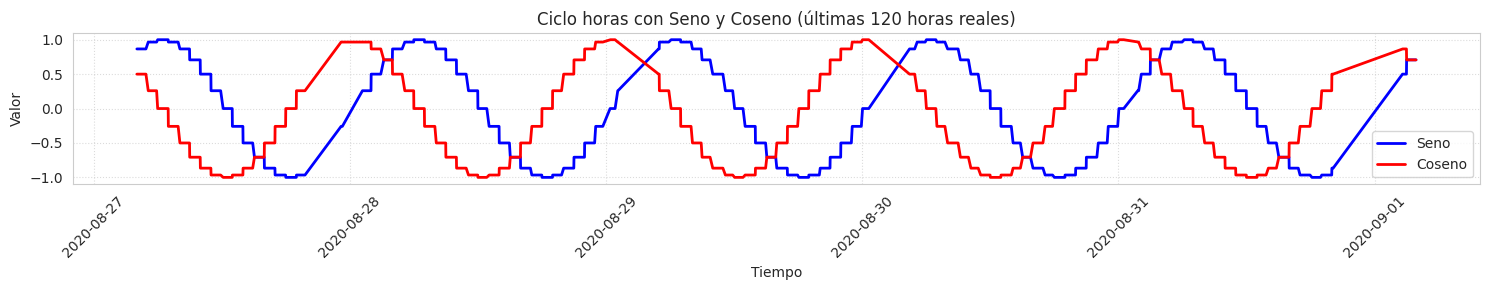

In [26]:
ts_fin   = df['timestamp'].max()
ts_inicio = ts_fin - pd.Timedelta(hours=120)

df_48 = df[
    (df['timestamp'] >= ts_inicio) &
    (df['timestamp'] <= ts_fin)
].copy()

print(f"Registros en últimas 48h: {len(df_48)}")
print(f"De: {df_48['timestamp'].min()}")
print(f"A:  {df_48['timestamp'].max()}")

plt.figure(figsize=(15, 3))
plt.plot(df_48['timestamp'], df_48['hora_sin'], label='Seno', color='blue', linewidth=2)
plt.plot(df_48['timestamp'], df_48['hora_cos'], label='Coseno', color='red', linewidth=2)

plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.title('Ciclo horas con Seno y Coseno (últimas 120 horas reales)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

## Features de dominio

In [5]:
Diferencia entre presión generada y reservorios (detecta fugas — exactamente tu tipo de falla)

df['delta_presion'] = df['TP3'] - df['Reservoirs']

Tiempo acumulado de operación en ventana

df['tiempo_operando_1h'] = df['operando'].rolling(3600).sum()

Temperatura relativa al inicio de sesión operacional (captura calentamiento anormal)

df['temp_incremento'] = df['Oil_temperature'].diff()

SyntaxError: invalid character '—' (U+2014) (3986979380.py, line 1)

## Componentes STL Tendencia y estacionalidad

## Lags de las originales y las de ingeniería

## Ponerle una etiqueta RUL basandome en el RUL_MAX = 24 Hrs.

---
### 1. Cargar df_op (datos operacionales)

### 2. Variables calendario (antes del filtrado ya están
###    en df_op porque se calcularon en preprocesamiento)
###    Si no: hora_sin, hora_cos, dia_sin, dia_cos

### 3. Features de dominio
###    delta_presion, ratio_carga, frecuencia_LPS, temp_rate

### 4. Componentes STL
###    Por sesión → tendencia y residuo de señales
###    crudas Y de features de dominio

### 5. Etiqueta RUL
###    Calcular sobre timestamps reales

### 6. Lags de TODO lo anterior
###    Señales crudas + features dominio + componentes STL
###    Dentro de cada sesión

### 7. Features estadísticas de ventana
###    media, std en ventanas de 15, 30, 60 min

### 8. Guardar dataset final